In [5]:
import pandas as pd
import numpy as np

# Please place the file "electricity-demand-dataset.csv" in your Google Drive folder named "Data" to run this cell.
# This allows you to access the dataset directly without re-uploading it each time you open the notebook in Google Colab.
# If you prefer not to host the file in Drive, modify the file path to read from the current working directory in Colab instead.

# from google.colab import drive
# drive.mount("/content/drive")

CSV_PATH = "electricity-demand-dataset.csv"
df = pd.read_csv(CSV_PATH).copy()

# --- Timestamp (date-only) ---
df["Timestamp_dt"] = pd.to_datetime(
    df["Timestamp"].astype(str).str.strip(),
    format="%d-%b-%y",
    errors="coerce"
)

# --- Fix hour (neighbor stepping) ---
h = pd.to_numeric(df["hour"], errors="coerce")

for i in range(1, len(h)):
    if pd.isna(h.iat[i]) and pd.notna(h.iat[i-1]):
        h.iat[i] = (int(h.iat[i-1]) + 1) % 24

for i in range(len(h) - 2, -1, -1):
    if pd.isna(h.iat[i]) and pd.notna(h.iat[i+1]):
        h.iat[i] = (int(h.iat[i+1]) - 1) % 24

# drop any rows where hour still missing
df = df.loc[~h.isna()].copy()
df["hour"] = h.loc[df.index].astype(int)

# --- Build ds ---
df["ds"] = df["Timestamp_dt"] + pd.to_timedelta(df["hour"], unit="h")

# --- Ensure numeric + interpolate continuous columns over time ---
df = df.sort_values("ds").reset_index(drop=True)
for col in ["Temperature", "Humidity", "Demand"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.set_index("ds")
df[["Temperature", "Humidity", "Demand"]] = df[["Temperature", "Humidity", "Demand"]].interpolate(
    method="time", limit_direction="both"
)
df = df.reset_index()

# quick sanity check
print(df[["ds","Demand","Temperature","Humidity"]].isna().sum())
print(df["ds"].min(), "->", df["ds"].max(), "| rows:", len(df))

ds             0
Demand         0
Temperature    0
Humidity       0
dtype: int64
2020-01-01 00:00:00 -> 2024-12-31 23:00:00 | rows: 43848


In [6]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import numpy as np

df = df.sort_values("ds").reset_index(drop=True)

def add_cyc_features(dfin):
    d = dfin.copy()
    hour = d["ds"].dt.hour.to_numpy()
    dow  = d["ds"].dt.weekday.to_numpy()
    doy  = d["ds"].dt.dayofyear.to_numpy()

    d["hour_sin"] = np.sin(2*np.pi*hour/24.0)
    d["hour_cos"] = np.cos(2*np.pi*hour/24.0)
    d["dow_sin"]  = np.sin(2*np.pi*dow/7.0)
    d["dow_cos"]  = np.cos(2*np.pi*dow/7.0)
    d["doy_sin"]  = np.sin(2*np.pi*doy/365.0)
    d["doy_cos"]  = np.cos(2*np.pi*doy/365.0)
    return d

class LSTMRegressor(nn.Module):
    def __init__(self, input_dim, hidden_dim=12, num_layers=2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True
        )
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        out, _ = self.lstm(x)          # out: (B, L, H)
        last = out[:, -1, :]           # (B, H)
        return self.fc(last)           # (B, 1)

def make_windows(df_feat, feature_cols, L=168):
    """
    One-step ahead windows:
      X_t = features[t-L : t]   (L timesteps)
      y_t = Demand[t]
    Split by target timestamp year: train targets in 2020-2023, test targets in 2024
    """
    Xall = df_feat[feature_cols].to_numpy(dtype=np.float32)
    yall = df_feat["Demand"].to_numpy(dtype=np.float32)
    years = df_feat["ds"].dt.year.to_numpy()
    ds_all = df_feat["ds"].to_numpy()

    X_list, y_list, ds_list = [], [], []
    for t in range(L, len(df_feat)):
        X_list.append(Xall[t-L:t])     # (L, d)
        y_list.append(yall[t])         # scalar
        ds_list.append(ds_all[t])      # target timestamp

    X = np.stack(X_list)              # (N, L, d)
    y = np.array(y_list).reshape(-1, 1)
    ds_t = np.array(ds_list)

    # target year decides split
    target_years = years[L:]
    tr_idx = np.where(target_years <= 2023)[0]
    te_idx = np.where(target_years == 2024)[0]

    return X, y, ds_t, tr_idx, te_idx

def train_eval_lstm(df_feat, feature_cols, title, L=6, epochs=100, batch_size=1024, lr=1e-3):
    # ---- CUDA / device setup ----
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"{title} | using device: {device}")

    X, y, ds_t, tr_idx, te_idx = make_windows(df_feat, feature_cols, L=L)

    Xtr, ytr = X[tr_idx], y[tr_idx]
    Xte, yte = X[te_idx], y[te_idx]
    ds_te = ds_t[te_idx]

    # scale features (fit on ALL timesteps from training windows)
    d = Xtr.shape[-1]
    x_scaler = RobustScaler().fit(Xtr.reshape(-1, d))
    Xtr_s = x_scaler.transform(Xtr.reshape(-1, d)).reshape(Xtr.shape).astype(np.float32)
    Xte_s = x_scaler.transform(Xte.reshape(-1, d)).reshape(Xte.shape).astype(np.float32)

    # scale target
    y_scaler = RobustScaler().fit(ytr)
    ytr_s = y_scaler.transform(ytr).astype(np.float32)

    # DataLoader: pin_memory helps GPU transfer when using CUDA
    use_cuda = (device.type == "cuda")
    tr_loader = DataLoader(
        TensorDataset(torch.from_numpy(Xtr_s), torch.from_numpy(ytr_s)),
        batch_size=batch_size,
        shuffle=True,
        pin_memory=use_cuda
    )

    model = LSTMRegressor(input_dim=d, hidden_dim=3, num_layers=1).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()

    model.train()
    for ep in range(epochs):
        tot = 0.0
        for xb, yb in tr_loader:
            # move batch to GPU (non_blocking works with pin_memory=True)
            xb = xb.to(device, non_blocking=use_cuda)
            yb = yb.to(device, non_blocking=use_cuda)

            pred = model(xb)
            loss = loss_fn(pred, yb)

            opt.zero_grad()
            loss.backward()
            opt.step()

            tot += loss.item() * xb.size(0)

        print(f"{title} | epoch {ep+1}/{epochs} | train MSE (scaled) = {tot/len(Xtr_s):.4f}")

    # ---- eval on test ----
    model.eval()
    with torch.no_grad():
        Xte_t = torch.from_numpy(Xte_s).to(device)
        yhat_s = model(Xte_t).detach().cpu().numpy()

    yhat = y_scaler.inverse_transform(yhat_s).reshape(-1)
    y_true = yte.reshape(-1)

    print(f"\n{title} | 2024 metrics:")
    print("MAE :", mean_absolute_error(y_true, yhat))
    print("RMSE:", np.sqrt(mean_squared_error(y_true, yhat)))
    print("R^2 :", r2_score(y_true, yhat))

    plt.figure()
    plt.plot(ds_te, y_true, label="Actual")
    plt.plot(ds_te, yhat, label="Predicted")
    plt.title(f"2024 Actual vs Predicted Demand ({title})")
    plt.xlabel("Time")
    plt.ylabel("Demand")
    plt.legend()
    plt.tight_layout()
    plt.show()

LSTM-1 (calendar-only) | using device: cuda
LSTM-1 (calendar-only) | epoch 1/100 | train MSE (scaled) = 0.5650
LSTM-1 (calendar-only) | epoch 2/100 | train MSE (scaled) = 0.4957
LSTM-1 (calendar-only) | epoch 3/100 | train MSE (scaled) = 0.4087
LSTM-1 (calendar-only) | epoch 4/100 | train MSE (scaled) = 0.3275
LSTM-1 (calendar-only) | epoch 5/100 | train MSE (scaled) = 0.2794
LSTM-1 (calendar-only) | epoch 6/100 | train MSE (scaled) = 0.2384
LSTM-1 (calendar-only) | epoch 7/100 | train MSE (scaled) = 0.1974
LSTM-1 (calendar-only) | epoch 8/100 | train MSE (scaled) = 0.1586
LSTM-1 (calendar-only) | epoch 9/100 | train MSE (scaled) = 0.1269
LSTM-1 (calendar-only) | epoch 10/100 | train MSE (scaled) = 0.1046
LSTM-1 (calendar-only) | epoch 11/100 | train MSE (scaled) = 0.0902
LSTM-1 (calendar-only) | epoch 12/100 | train MSE (scaled) = 0.0805
LSTM-1 (calendar-only) | epoch 13/100 | train MSE (scaled) = 0.0731
LSTM-1 (calendar-only) | epoch 14/100 | train MSE (scaled) = 0.0667
LSTM-1 (calen

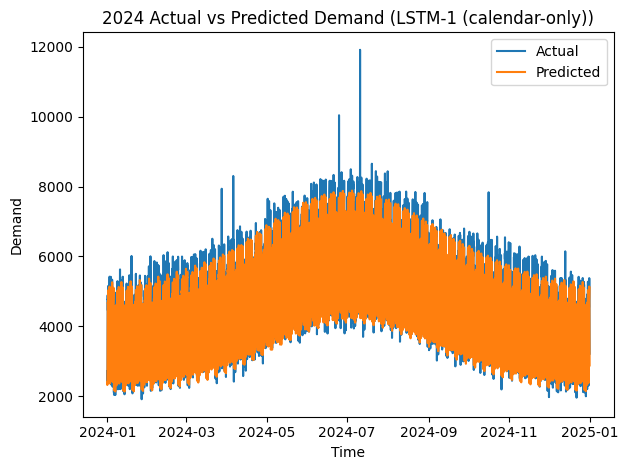

In [4]:
L = 24*7
df1 = add_cyc_features(df)

feat1 = ["hour_sin","hour_cos","dow_sin","dow_cos","doy_sin","doy_cos"]
train_eval_lstm(df1, feat1, title="LSTM-1 (calendar-only)", L=L, epochs=100)

LSTM-2 (calendar + temp/humidity) | using device: cuda
LSTM-2 (calendar + temp/humidity) | epoch 1/100 | train MSE (scaled) = 0.5414
LSTM-2 (calendar + temp/humidity) | epoch 2/100 | train MSE (scaled) = 0.5137
LSTM-2 (calendar + temp/humidity) | epoch 3/100 | train MSE (scaled) = 0.4831
LSTM-2 (calendar + temp/humidity) | epoch 4/100 | train MSE (scaled) = 0.4421
LSTM-2 (calendar + temp/humidity) | epoch 5/100 | train MSE (scaled) = 0.3950
LSTM-2 (calendar + temp/humidity) | epoch 6/100 | train MSE (scaled) = 0.3449
LSTM-2 (calendar + temp/humidity) | epoch 7/100 | train MSE (scaled) = 0.2957
LSTM-2 (calendar + temp/humidity) | epoch 8/100 | train MSE (scaled) = 0.2466
LSTM-2 (calendar + temp/humidity) | epoch 9/100 | train MSE (scaled) = 0.1998
LSTM-2 (calendar + temp/humidity) | epoch 10/100 | train MSE (scaled) = 0.1593
LSTM-2 (calendar + temp/humidity) | epoch 11/100 | train MSE (scaled) = 0.1302
LSTM-2 (calendar + temp/humidity) | epoch 12/100 | train MSE (scaled) = 0.1122
LSTM-2

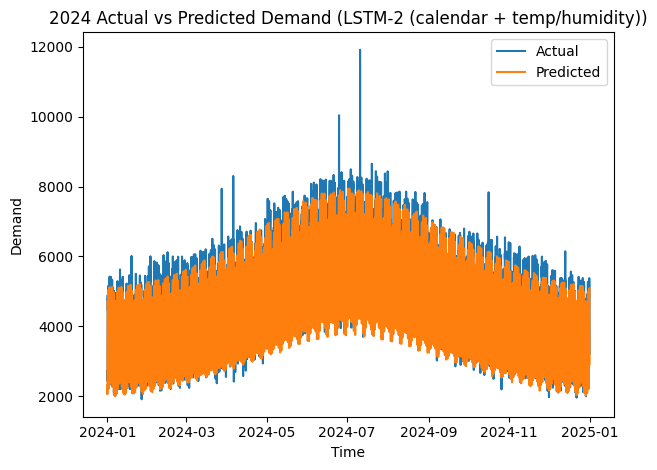

In [7]:
L = 24*7
df2 = add_cyc_features(df)

feat2 = ["hour_sin","hour_cos","dow_sin","dow_cos","doy_sin","doy_cos",
         "Temperature","Humidity"]
train_eval_lstm(df2, feat2, title="LSTM-2 (calendar + temp/humidity)", L=L, epochs=100)

LSTM-3 (calendar + temp/humidity + demand history) | using device: cuda
LSTM-3 (calendar + temp/humidity + demand history) | epoch 1/100 | train MSE (scaled) = 0.7293
LSTM-3 (calendar + temp/humidity + demand history) | epoch 2/100 | train MSE (scaled) = 0.5833
LSTM-3 (calendar + temp/humidity + demand history) | epoch 3/100 | train MSE (scaled) = 0.4444
LSTM-3 (calendar + temp/humidity + demand history) | epoch 4/100 | train MSE (scaled) = 0.3364
LSTM-3 (calendar + temp/humidity + demand history) | epoch 5/100 | train MSE (scaled) = 0.2483
LSTM-3 (calendar + temp/humidity + demand history) | epoch 6/100 | train MSE (scaled) = 0.1816
LSTM-3 (calendar + temp/humidity + demand history) | epoch 7/100 | train MSE (scaled) = 0.1372
LSTM-3 (calendar + temp/humidity + demand history) | epoch 8/100 | train MSE (scaled) = 0.1106
LSTM-3 (calendar + temp/humidity + demand history) | epoch 9/100 | train MSE (scaled) = 0.0945
LSTM-3 (calendar + temp/humidity + demand history) | epoch 10/100 | train

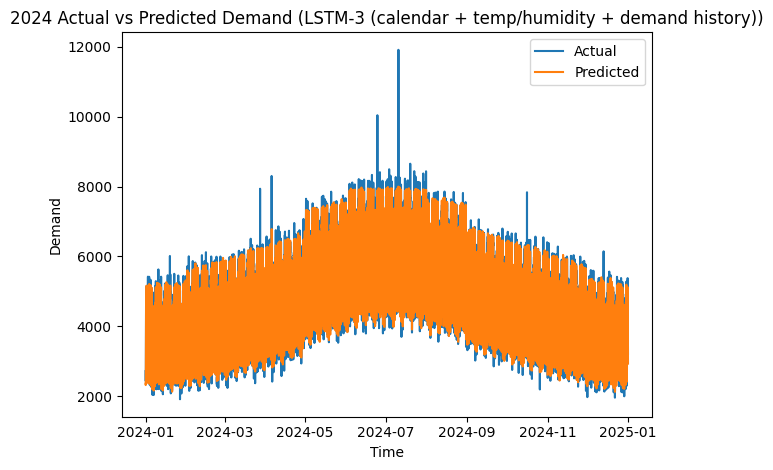

In [8]:
L = 24*7
df3 = add_cyc_features(df).copy()

# include Demand as an input feature at each timestep (this is the LSTM equivalent of “lags”)
df3["Demand_in"] = df3["Demand"]

feat3 = ["Demand_in",
         "hour_sin","hour_cos","dow_sin","dow_cos","doy_sin","doy_cos",
         "Temperature","Humidity"]

train_eval_lstm(df3, feat3, title="LSTM-3 (calendar + temp/humidity + demand history)", L=L, epochs=100)